In [12]:
import pandas as pd

df = pd.read_csv(r"C:\Users\chaud\OneDrive\Desktop\sales-profit-analysis\data\Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
df.shape

(9994, 21)

In [38]:
category_profit = df.groupby(['Category', 'Sub-Category'])['Profit'].sum().sort_values(ascending=False)
category_profit

Category         Sub-Category
Technology       Copiers         55617.8249
                 Phones          44515.7306
                 Accessories     41936.6357
Office Supplies  Paper           34053.5693
                 Binders         30221.7633
Furniture        Chairs          26590.1663
Office Supplies  Storage         21278.8264
                 Appliances      18138.0054
Furniture        Furnishings     13059.1436
Office Supplies  Envelopes        6964.1767
                 Art              6527.7870
                 Labels           5546.2540
Technology       Machines         3384.7569
Office Supplies  Fasteners         949.5182
                 Supplies        -1189.0995
Furniture        Bookcases       -3472.5560
                 Tables         -17725.4811
Name: Profit, dtype: float64

## Category & Sub-Category Profit
Technology sub-categories dominate profit. Furniture "Tables" is the biggest loss-maker.


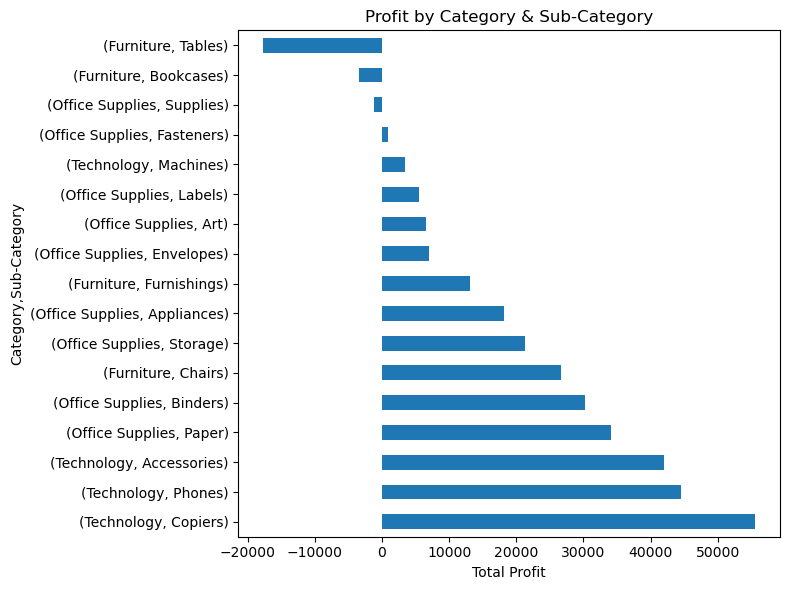

In [40]:
import matplotlib.pyplot as plt

category_profit.plot(kind='barh', figsize=(8,6))
plt.xlabel('Total Profit')
plt.title('Profit by Category & Sub-Category')
plt.tight_layout()
plt.savefig(r'C:\Users\chaud\OneDrive\Desktop\sales-profit-analysis\images\category_profit.png')
plt.show()

## Regional Profit
All four regions are profitable. West earns almost 3x what Central does, showing room for regional growth.

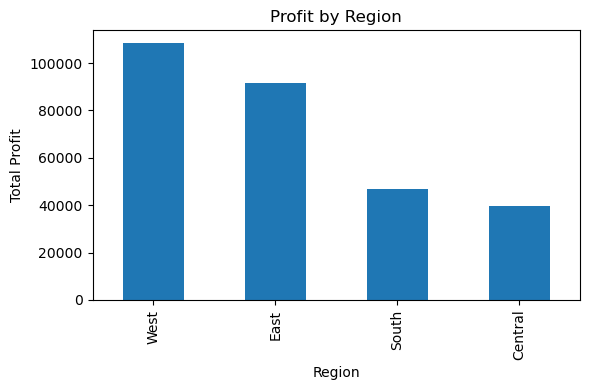

In [42]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_profit.plot(kind='bar', figsize=(6,4))
plt.ylabel('Total Profit')
plt.title('Profit by Region')
plt.tight_layout()
plt.savefig(r"C:\Users\chaud\OneDrive\Desktop\sales-profit-analysis\images\region_profit.png")
plt.show()

## Discount vs. Profit
Profit steadily declines as discount increases, turning negative once discount exceeds ~20%.

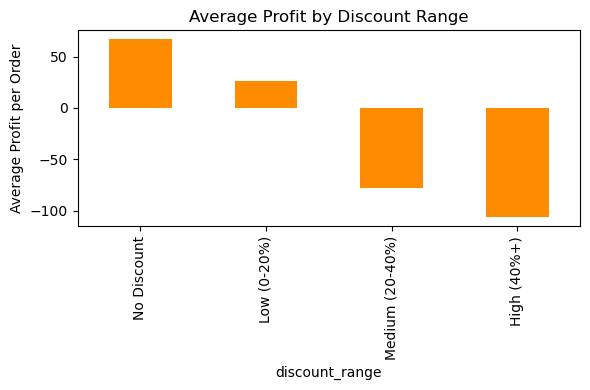

In [44]:
def bucket(d):
    if d == 0:
        return 'No Discount'
    elif d <= 0.2:
        return 'Low (0-20%)'
    elif d <= 0.4:
        return 'Medium (20-40%)'
    else:
        return 'High (40%+)'

df['discount_range'] = df['Discount'].apply(bucket)

discount_profit = df.groupby('discount_range')['Profit'].mean().sort_values(ascending=False)
discount_profit.plot(kind='bar', figsize=(6,4), color='darkorange')
plt.ylabel('Average Profit per Order')
plt.title('Average Profit by Discount Range')
plt.tight_layout()
plt.savefig(r"C:\Users\chaud\OneDrive\Desktop\sales-profit-analysis\images\discount_profit.png")
plt.show()